In [1]:
import hashlib
import json
import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("numpy", np.__version__)
print("pandas", pd.__version__)

numpy 1.26.3
pandas 2.2.2


In [9]:
prices = pd.read_parquet("raw_dataset.parquet")
prices

,SBER,SBERP,GAZP,LKOH,ROSN,NVTK,TATN,TATNP,GMKN,CHMF,NLMK,MAGN,ALRS,PLZL,PHOR,MGNT,MTSS,RTKM,SNGS,SNGSP,AFKS,MOEX,VTBR,YDEX,AFLT,FEES,IRAO,HYDR,TRNFP,BSPB,PIKK,FIVE,UPRO,CBOM,VKCO,T,OZON,POSI,RUAL,ENPG,SPBE,ASTR,FESH,NMTP,BELU,HEAD,LSRG,MSNG,TGKN,UNAC,CNTL,RNFT,FLOT,SMLT,SOFL,DELI,SBMX,SBRB,LQDT,TITR,EQMX,AKMB,SBCB,SBGB,FXUS,FXCN,FXIT,FXMM,SBHI,TBRU,TMOS,TECH,SU26238RMFS4,SU26243RMFS4,SU26244RMFS2,SU26233RMFS5,SU26234RMFS3,USD000UTSTOM,EUR_RUB__TOM,CHFRUB_TOM,JPYRUB_TOM,KZTRUB_TOM,BYNRUB_TOM,GLDRUB_TOM,SLVRUB_TOM,PLDRUB_TOM
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,1.008979,1.004737,1.011415,1.030214,1.008765,1.004553,1.022635,0.997506,1.018269,1.025778,0.988126,1.006908,1.046912,1.008741,0.993298,0.998592,1.011034,0.983277,1.003965,1.004807,1.026644,1.026674,0.975774,NaN,0.968861,1.023794,1.112647,1.037087,1.014599,0.993143,0.989327,NaN,NaN,0.983461,NaN,NaN,NaN,NaN,1.027123,NaN,NaN,NaN,1.011111,0.978408,NaN,NaN,1.027937,1.040804,1.021930,1.039926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.015779,1.000000,1.011450,1.000167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.002132,0.993338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-06,0.988164,0.982945,1.007635,1.029348,1.005578,0.994746,1.029148,0.990025,1.007622,1.070974,0.988126,1.023911,1.044919,1.010490,0.996825,0.995953,1.007436,0.999887,0.998678,0.997940,1.025794,1.028198,0.973831,NaN,0.961744,1.017929,1.154941,1.024977,1.037539,0.997714,0.986079,NaN,NaN,0.988550,NaN,NaN,NaN,NaN,1.022232,NaN,NaN,NaN,1.018519,0.997301,NaN,NaN,1.048711,1.034105,1.021930,0.984215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.026824,1.007371,1.015614,1.000668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.021870,1.017287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11,0.928783,0.935436,0.973834,0.977361,0.960359,0.964098,0.987136,0.976559,0.963909,1.035989,0.996910,0.992827,1.016301,1.059441,0.991182,0.954317,0.962101,0.977627,0.975037,0.993362,0.996315,1.028851,0.936002,NaN,0.926335,0.984249,1.109394,1.000606,1.046924,0.982857,0.969374,NaN,NaN,0.986005,NaN,NaN,NaN,NaN,0.991552,NaN,NaN,NaN,1.003704,0.990553,NaN,NaN,0.996418,1.003654,0.973684,0.942433,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.003156,0.963145,0.988203,1.000835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.041703,1.044543,NaN,NaN,NaN,NaN,inf,inf,NaN
2016-01-12,0.935721,0.938278,0.989845,0.962471,0.955777,0.992995,0.995603,0.962594,0.958642,1.037831,1.023285,0.971573,1.056693,1.111888,0.997531,0.927478,0.983449,0.966102,1.001468,1.007553,0.995465,1.020686,0.953750,NaN,0.947509,0.987768,1.101261,1.025583,1.056830,0.995429,0.974942,NaN,NaN,0.972010,NaN,NaN,NaN,NaN,0.995998,NaN,NaN,NaN,1.007407,0.975709,NaN,NaN,0.975645,1.007917,0.991228,0.899721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.016963,0.975430,1.010409,1.001085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.053376,1.055521,NaN,NaN,NaN,NaN,inf,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-24,5.621107,7.589444,2.216676,5.750005,3.266478,2.952950,4.672223,7.208750,3.032147,3.407579,3.470186,2.685190,1.031169,12.214659,6.859639

In [10]:
prices.isna().mean().sort_values(ascending=False)

TECH            0.954076
T               0.863758
PLDRUB_TOM      0.851894
HEAD            0.845006
YDEX            0.827401
                  ...   
CBOM            0.006889
SBERP           0.006889
SBER            0.006889
USD000UTSTOM    0.000000
EUR_RUB__TOM    0.000000
Length: 86, dtype: float64

In [11]:
sum(prices.isna().mean().values > 0.15)

40

In [12]:
prices_close = pd.read_parquet("raw_absolute_prices.parquet")
prices_close

,SBER,SBERP,GAZP,LKOH,ROSN,NVTK,TATN,TATNP,GMKN,CHMF,NLMK,MAGN,ALRS,PLZL,PHOR,MGNT,MTSS,RTKM,SNGS,SNGSP,AFKS,MOEX,VTBR,YDEX,AFLT,FEES,IRAO,HYDR,TRNFP,BSPB,PIKK,FIVE,UPRO,CBOM,VKCO,T,OZON,POSI,RUAL,ENPG,SPBE,ASTR,FESH,NMTP,BELU,HEAD,LSRG,MSNG,TGKN,UNAC,CNTL,RNFT,FLOT,SMLT,SOFL,DELI,SBMX,SBRB,LQDT,TITR,EQMX,AKMB,SBCB,SBGB,FXUS,FXCN,FXIT,FXMM,SBHI,TBRU,TMOS,TECH,SU26238RMFS4,SU26243RMFS4,SU26244RMFS2,SU26233RMFS5,SU26234RMFS3,USD000UTSTOM,EUR_RUB__TOM,CHFRUB_TOM,JPYRUB_TOM,KZTRUB_TOM,BYNRUB_TOM,GLDRUB_TOM,SLVRUB_TOM,PLDRUB_TOM
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-04,98.01,73.88,134.91,2310.2,251.00,571.0,307.05,200.5,8922.00,597.4,61.48,18.820,55.21,2860.0,2835.0,11366.0,208.45,88.50,34.050,43.690,17.640,91.85,0.07719,NaN,56.20,0.05968,1.2295,0.6606,191800.0,43.75,215.5,NaN,NaN,3.930,NaN,NaN,NaN,NaN,22.490,NaN,NaN,NaN,2.70,3.705,NaN,NaN,698.0,0.8210,0.001140,0.5385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2535.0,2035.0,2882.0,1198.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.1600,79.250,NaN,NaN,NaN,NaN,0.0,0.00,NaN
2016-01-05,98.89,74.23,136.45,2380.0,253.20,573.6,314.00,200.0,9085.00,612.8,60.75,18.950,57.80,2885.0,2816.0,11350.0,210.75,87.02,34.185,43.900,18.110,94.30,0.07532,NaN,54.45,0.06110,1.3680,0.6851,194600.0,43.45,213.2,NaN,NaN,3.865,NaN,NaN,NaN,NaN,23.100,NaN,NaN,NaN,2.73,3.625,NaN,NaN,717.5,0.8545,0.001165,0.5600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2575.0,2035.0,2915.0,1198.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.3160,78.722,NaN,NaN,NaN,NaN,0.0,0.00,NaN
2016-01-06,96.85,72.62,135.94,2378.0,252.40,568.0,316.00,198.5,8990.00,639.8,60.75,19.270,57.69,2890.0,2826.0,11320.0,210.00,88.49,34.005,43.600,18.095,94.44,0.07517,NaN,54.05,0.06075,1.4200,0.6771,199000.0,43.65,212.5,NaN,NaN,3.885,NaN,NaN,NaN,NaN,22.990,NaN,NaN,NaN,2.75,3.695,NaN,NaN,732.0,0.8490,0.001165,0.5300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2603.0,2050.0,2927.0,1199.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.7600,80.620,NaN,NaN,NaN,NaN,0.0,0.00,NaN
2016-01-11,91.03,69.11,131.38,2257.9,241.05,550.5,303.10,195.8,8600.00,618.9,59.34,18.685,56.11,3030.0,2810.0,10667.0,200.55,86.52,33.200,43.400,17.575,94.50,0.07225,NaN,52.06,0.05874,1.3640,0.6610,200800.0,43.00,208.9,NaN,NaN,3.875,NaN,NaN,NaN,NaN,22.300,NaN,NaN,NaN,2.71,3.670,NaN,NaN,695.5,0.8240,0.001110,0.5075,21.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2543.0,1960.0,2848.0,1199.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.2110,82.780,NaN,NaN,NaN,NaN,2690.1,34.20,NaN
2016-01-12,91.71,69.32,133.54,2223.5,239.90,567.0,305.70,193.0,8553.00,620.0,60.91,18.285,58.34,3180.0,2828.0,10367.0,205.00,85.50,34.100,44.020,17.560,93.75,0.07362,NaN,53.25,0.05895,1.3540,0.6775,202700.0,43.55,210.1,NaN,NaN,3.820,NaN,NaN,NaN,NaN,22.400,NaN,NaN,NaN,2.72,3.615,NaN,NaN,681.0,0.8275,0.001130,0.4845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2578.0,1985.0,2912.0,1199.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.0650,83.650,NaN,NaN,NaN,NaN,2653.0,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-24,325.19,325.10,123.25,5476.5,437.45,1184.0,594.90,557.7,137.76,800.2,90.92,26.170,29.96,2289.8,7019.0,2768.5,223.20,56.04,20.325,43.420,11.941,173.39,94.24000,4284.5,48.99,0.07012,3.2405,0.4183,1384.8,338.30,534.5,NaN,1.4060,6.489,262.10,320.16,4348.0,1075.2,41.250,446.05,218.4,267.5,78.82,8.400,389.8,2972.0,657.8,1.9650,0.005840,0.3960,9.10,114.10,82.41,635.8,70.90,83.30,18.578,18.689,1.9765,5.32,142.20,1.9742,1335.0,15.688,NaN,NaN,NaN,NaN,7.342,8.24,6.47,NaN,59.030,75.325,86.602,60.112,NaN,74.6900,0.000,0.0,0.0,16.5600,26.5700,11345.0,185.00,3555.50
2026-04-27,321.99,322.11,123.29,5553.0,439.95,117

In [13]:
assets_df = pd.read_parquet("assets_df.parquet")
assets_df

,engine,market,board,asset_type
secid,,,,
AFKS,stock,shares,TQBR,equity
AFLT,stock,shares,TQBR,equity
AKMB,stock,shares,TQTF,fund
ALRS,stock,shares,TQBR,equity
ASTR,stock,shares,TQBR,equity
...,...,...,...,...
UPRO,stock,shares,TQBR,equity
USD000UTSTOM,currency,selt,CETS,fx
VKCO,stock,shares,TQBR,equity


In [18]:
MOEX_BASE = "https://iss.moex.com/iss"
MOEX_HTTP_TIMEOUT: Tuple[float, float] = (10.0, 60.0)

def _get_json(
    url: str,
    params: Optional[dict] = None,
    timeout: Optional[Tuple[float, float]] = None,
    max_retries: int = 3,
) -> dict:
    tout = timeout if timeout is not None else MOEX_HTTP_TIMEOUT
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params or {}, timeout=tout)
            r.raise_for_status()
            return r.json()
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError):
            if attempt >= max_retries - 1:
                raise
            time.sleep(0.5 * (attempt + 1))

def moex_security_info(secid: str, engine: str = "stock", market: str = "shares") -> dict:
    """Возвращает базовую инфу о бумаге, включая LOTSIZE (если доступно)."""
    url = f"{MOEX_BASE}/engines/{engine}/markets/{market}/securities/{secid}.json"
    js = _get_json(url, params={"iss.meta": "off"})

    sec_cols = js["securities"]["columns"]
    sec_data = js["securities"]["data"]
    sec = (pd.DataFrame(sec_data, columns=sec_cols).iloc[0].to_dict()) if len(sec_data) else {}

    mdata_cols = js.get("marketdata", {}).get("columns", [])
    mdata_data = js.get("marketdata", {}).get("data", [])
    mdata = (pd.DataFrame(mdata_data, columns=mdata_cols).iloc[0].to_dict()) if len(mdata_data) else {}

    return {**sec, **{f"MD_{k}": v for k, v in mdata.items()}}


def load_lot_sizes_assets(assets: List[dict]) -> pd.Series:
    lot = {}
    for a in tqdm(list(assets), desc="MOEX security info (multi-asset)"):
        secid = a["secid"]
        info = moex_security_info(
            secid,
            engine=a.get("engine", "stock"),
            market=a.get("market", "shares"),
        )
        lotsize = info.get("LOTSIZE")
        lot[secid] = int(lotsize) if lotsize not in (None, "", np.nan) else 1
        time.sleep(0.05)
    return pd.Series(lot, name="LOTSIZE").astype(int)

Исключены активы (последнее значение 0 или есть inf): ['CHFRUB_TOM', 'EUR_RUB__TOM', 'GLDRUB_TOM', 'SLVRUB_TOM']


MOEX security info (multi-asset):   0%|          | 0/56 [00:00<?, ?it/s]

,engine,market,board,asset_type
SBER,stock,shares,TQBR,equity
SBERP,stock,shares,TQBR,equity
GAZP,stock,shares,TQBR,equity
LKOH,stock,shares,TQBR,equity
ROSN,stock,shares,TQBR,equity
NVTK,stock,shares,TQBR,equity
TATN,stock,shares,TQBR,equity
TATNP,stock,shares,TQBR,equity
GMKN,stock,shares,TQBR,equity
CHMF,stock,shares,TQBR,equity


SBER            1
SBERP           1
GAZP            1
LKOH            1
ROSN            1
NVTK            1
TATN            1
TATNP           1
GMKN            1
CHMF            1
NLMK            1
MAGN            1
ALRS            1
PLZL            1
PHOR            1
MGNT            1
MTSS            1
RTKM            1
SNGS            1
SNGSP           1
AFKS            1
MOEX            1
VTBR            1
AFLT            1
FEES            1
IRAO            1
HYDR            1
TRNFP           1
BSPB            1
PIKK            1
UPRO            1
CBOM            1
RUAL            1
FESH            1
NMTP            1
LSRG            1
MSNG            1
TGKN            1
UNAC            1
CNTL            1
RNFT            1
USD000UTSTOM    1
Name: LOTSIZE, dtype: int32

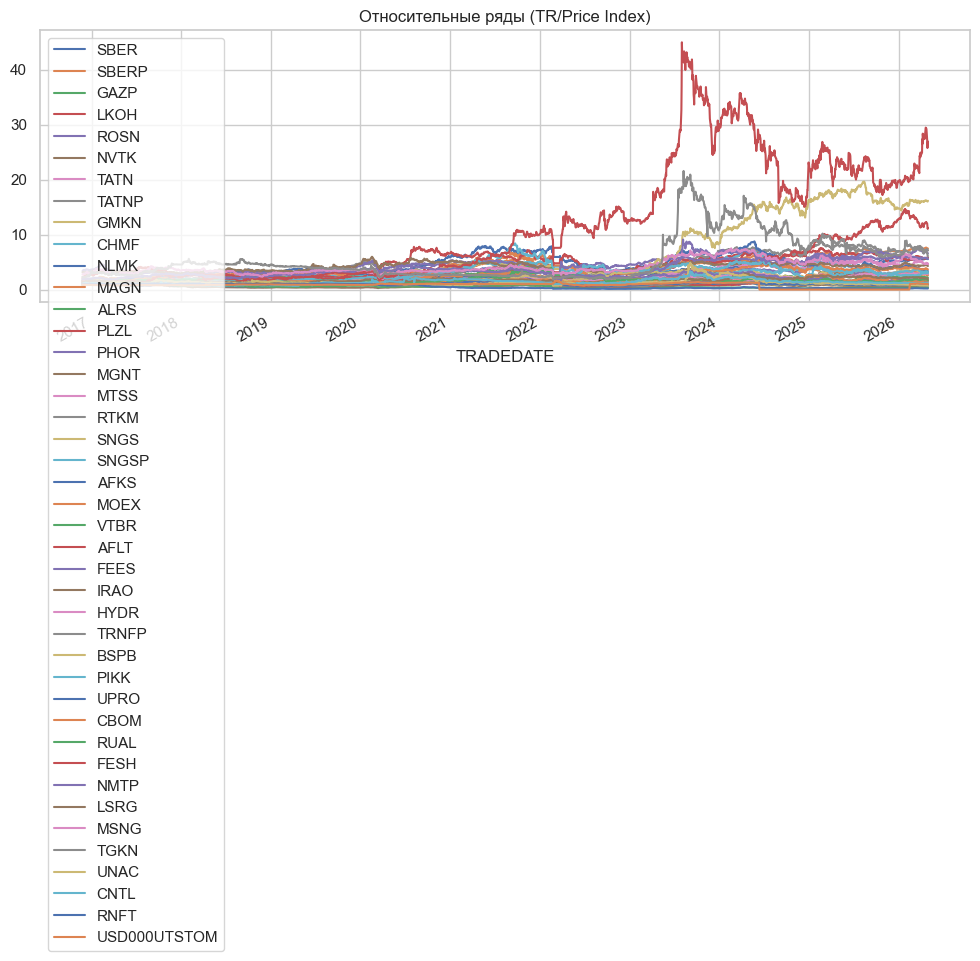

In [23]:
SECIDS = [
    "SBER",
    "SBERP",
    "GAZP",
    "LKOH",
    "ROSN",
    "NVTK",
    "TATN",
    "TATNP",
    "GMKN",
    "CHMF",
    "NLMK",
    "MAGN",
    "ALRS",
    "PLZL",
    "PHOR",
    "MGNT",
    "MTSS",
    "RTKM",
    "SNGS",
    "SNGSP",
    "AFKS",
    "MOEX",
    "VTBR",
    "YDEX",
    "AFLT",
    "FEES",
    "IRAO",
    "HYDR",
    "TRNFP",
    "BSPB",
    "PIKK",
    "FIVE",
    "UPRO",
    "CBOM",
    "VKCO",
    "T",
    "OZON",
    "POSI",
    "RUAL",
    "ENPG",
    "SPBE",
    "ASTR",
    "FESH",
    "NMTP",
    "BELU",
    "HEAD",
    "LSRG",
    "MSNG",
    "TGKN",
    "UNAC",
    "CNTL",
    "RNFT",
    "FLOT",
    "SMLT",
    "SOFL",
    "DELI",
]


# Универсум активов (можно менять/расширять)
# asset_type: equity | fund | bond | fx | metal
ASSETS: List[dict] = []

# Акции (TQBR)
ASSETS += [
    {"secid": s, "engine": "stock", "market": "shares", "board": "TQBR", "asset_type": "equity"}
    for s in SECIDS
]

# Чтобы расчёты были стабильнее, отфильтруем активы с большим числом пропусков
max_nan_share = 0.15

# фильтрация на относительных рядах (prices)
keep = prices.columns[prices.isna().mean() <= max_nan_share]
prices = prices[keep].dropna(how="all").ffill().dropna()

# убираем активы с нулём в последней точке или с inf в ряду
_last = prices.iloc[-1]
_has_inf = pd.Series(np.isinf(prices.to_numpy(dtype=float)).any(axis=0), index=prices.columns)
_ok = (_last != 0) & (~_has_inf)
removed = sorted(prices.columns[~_ok].tolist())
if removed:
    print("Исключены активы (последнее значение 0 или есть inf):", removed)
prices = prices.loc[:, _ok]

# синхронизируем absolute цены и метаданные
prices_close = prices_close[prices.columns].ffill().dropna()
assets_df = assets_df.loc[prices.columns]

lot_size = load_lot_sizes_assets(ASSETS)
lot_size = lot_size.reindex(prices.columns).fillna(1).astype(int)

display(assets_df)
display(lot_size)

prices.plot(figsize=(12, 4), title="Относительные ряды (TR/Price Index)")
plt.show()

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def portfolio_metrics_rolling(
    weights: dict[str, float] | pd.Series,
    prices: pd.DataFrame,
    window: int = 252,
    trading_days: int = 252,
    normalize: bool = True,
    allow_short: bool = False,
    plot: bool = True,
) -> dict:
    """
    Считает доходность и rolling-риск портфеля.

    weights: {"SBER": 0.4, "GAZP": 0.6}
    prices: DataFrame цен по тикерам
    window: размер rolling-окна, обычно 252 торговых дня
    """

    w = pd.Series(weights, dtype=float)

    if not allow_short and (w < 0).any():
        bad = w[w < 0]
        raise ValueError(f"Negative weights are not allowed: {bad.to_dict()}")

    missing = [t for t in w.index if t not in prices.columns]
    if missing:
        raise KeyError(f"Tickers not found in prices: {missing}")

    if normalize:
        s = float(w.sum())
        if s == 0:
            raise ValueError("Sum of weights is 0.")
        w = w / s

    tickers = list(w.index)
    prices_sub = prices[tickers]

    logret = np.log(prices_sub / prices_sub.shift(1)).dropna()

    # доходность портфеля во времени
    portfolio_ret_daily = logret @ w

    mu_daily = portfolio_ret_daily.mean()
    mu_ann = float(mu_daily * trading_days)

    # rolling covariance matrices
    rolling_cov = logret.rolling(window).cov()

    rolling_var = []

    for date in logret.index[window - 1:]:
        cov_t = rolling_cov.loc[date].loc[tickers, tickers]
        var_t = float(w.values @ cov_t.values @ w.values)
        rolling_var.append((date, var_t * trading_days))

    rolling_var = pd.Series(
        data=[x[1] for x in rolling_var],
        index=[x[0] for x in rolling_var],
        name="rolling_var_ann"
    )

    rolling_sigma = np.sqrt(rolling_var.clip(lower=0))
    rolling_sigma.name = "rolling_sigma_ann"

    sigma_q_0_8 = rolling_sigma.quantile(0.8)
    sigma_q_0_9 = rolling_sigma.quantile(0.9)
    sigma_q_0_95 = rolling_sigma.quantile(0.95)

    result = {
        "weights": w,
        "mu_ann": mu_ann,
        "rolling_var_ann": rolling_var,
        "rolling_sigma_ann": rolling_sigma,
        "mean_var_ann": float(rolling_var.mean()),
        "median_var_ann": float(rolling_var.median()),
        "mean_sigma_ann": float(rolling_sigma.mean()),
        "median_sigma_ann": float(rolling_sigma.median()),
        "sigma_q_0.8": sigma_q_0_8,
        "sigma_q_0.9": sigma_q_0_9,
        "sigma_q_0.95": sigma_q_0_95,

    }

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(rolling_var.index, rolling_var.values, label="Rolling portfolio variance")
        plt.title(f"Rolling Portfolio Variance, window={window}")
        plt.xlabel("Date")
        plt.ylabel("Annualized variance")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(rolling_sigma.index, rolling_sigma.values, label="Rolling portfolio sigma")
        plt.title(f"Rolling Portfolio Risk / Volatility, window={window}")
        plt.xlabel("Date")
        plt.ylabel("Annualized sigma")
        plt.legend()
        plt.grid(True)
        plt.show()

    return result

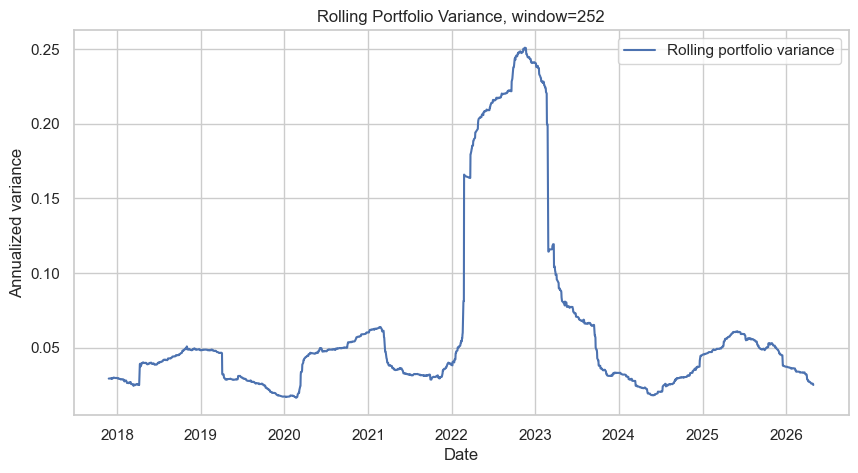

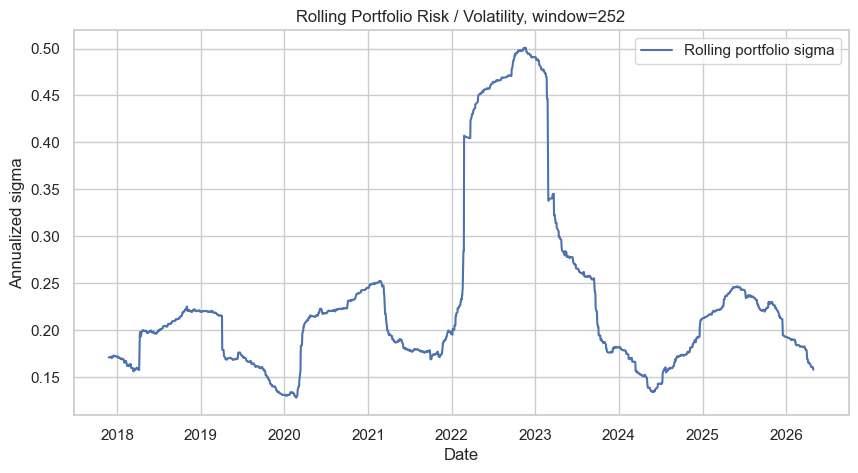

{'weights': SBER    0.5
 LKOH    0.1
 PHOR    0.4
 dtype: float64,
 'mu_ann': 0.15952017091210122,
 'rolling_var_ann': 2017-11-24    0.029284
 2017-11-27    0.029345
 2017-11-28    0.029295
 2017-11-29    0.029349
 2017-11-30    0.029440
                 ...   
 2026-04-24    0.025831
 2026-04-27    0.025921
 2026-04-28    0.025723
 2026-04-29    0.025712
 2026-04-30    0.024990
 Name: rolling_var_ann, Length: 2135, dtype: float64,
 'rolling_sigma_ann': 2017-11-24    0.171127
 2017-11-27    0.171305
 2017-11-28    0.171159
 2017-11-29    0.171315
 2017-11-30    0.171582
                 ...   
 2026-04-24    0.160719
 2026-04-27    0.160999
 2026-04-28    0.160384
 2026-04-29    0.160349
 2026-04-30    0.158082
 Name: rolling_sigma_ann, Length: 2135, dtype: float64,
 'mean_var_ann': 0.0627264710802458,
 'median_var_ann': 0.044048260807066676,
 'mean_sigma_ann': 0.23214547971225824,
 'median_sigma_ann': 0.2098767752922335,
 'sigma_q_0.8': 0.2489792754044934,
 'sigma_q_0.9': 0.4420604366

In [47]:
portfolio_metrics_rolling(
    {"SBER": 0.5,  "LKOH": 0.1, "PHOR": 0.4},
    prices
)

## Эволюционная оптимизация портфеля (DEAP)

**Цель:** максимизировать `mu_ann` (ожидаемая годовая доходность по лог-доходностям).

**Ограничение:** `sigma_q_0.9 ≤ sigma_max` (90-й перцентиль rolling-годовой волатильности, как в `portfolio_metrics_rolling`).

Сравниваются три подхода: **штраф** (все активы), **штраф + cardinality** (не более K=10 активов), **death penalty**. Внутри GA используется быстрый пересчёт на предвычисленном тензоре ковариаций; финальная проверка — полный вызов `portfolio_metrics_rolling`.

In [48]:
try:
    import deap  # noqa: F401
except ImportError:
    %pip install -q deap

import random
from typing import Callable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from deap import algorithms, base, creator, tools

Note: you may need to restart the kernel to use updated packages.


In [55]:
from typing import List

# --- Параметры, совпадающие с portfolio_metrics_rolling по умолчанию ---
EA_WINDOW = 252
EA_TRADING_DAYS = 252

# Нули/отрицательные цены дают log(0)->-inf; dropna() их не убирает — из-за этого mean/@ давали NaN.
_px = prices.astype(np.float64).replace(0, np.nan).ffill().bfill()
_ratio = _px / _px.shift(1)
logret_df = np.log(_ratio)
logret_df = logret_df.replace([np.inf, -np.inf], np.nan).dropna(how="any")
EA_TICKERS: List[str] = list(logret_df.columns)
EA_N = len(EA_TICKERS)
LOGRET_MAT = np.ascontiguousarray(logret_df.values.astype(np.float64))

# Тензор rolling-ковариаций (дневные), как в portfolio_metrics_rolling
rolling_cov = logret_df.rolling(EA_WINDOW).cov()
eval_dates = logret_df.index[EA_WINDOW - 1 :]
T_cov = len(eval_dates)
COV_TENSOR = np.empty((T_cov, EA_N, EA_N), dtype=np.float64)
for ti, date in enumerate(eval_dates):
    block = rolling_cov.loc[date].loc[EA_TICKERS, EA_TICKERS].values.astype(np.float64)
    COV_TENSOR[ti] = np.nan_to_num(block, nan=0.0, posinf=0.0, neginf=0.0)


def metrics_from_weights_vec(w: np.ndarray) -> Tuple[float, float]:
    """Возвращает (mu_ann, sigma_q_0.9) в согласовании с portfolio_metrics_rolling."""
    w = np.asarray(w, dtype=np.float64)
    s = w.sum()
    if s <= 0:
        w = np.ones(EA_N, dtype=np.float64) / EA_N
    else:
        w = w / s
    port_daily = LOGRET_MAT @ w
    mu_ann = float(np.nanmean(port_daily) * EA_TRADING_DAYS)
    var_t = np.einsum("i,tij,j->t", w, COV_TENSOR, w) * EA_TRADING_DAYS
    sigma_t = np.sqrt(np.clip(var_t, 0.0, None))
    sigma_q_09 = float(np.nanquantile(sigma_t, 0.9))
    return mu_ann, sigma_q_09


def vec_from_weight_dict(d: dict) -> np.ndarray:
    w = np.zeros(EA_N, dtype=np.float64)
    for t, v in d.items():
        if t in EA_TICKERS:
            w[EA_TICKERS.index(t)] = float(v)
    s = w.sum()
    if s > 0:
        w /= s
    return w


# Сверка с portfolio_metrics_rolling на примере из ноутбука
_check = {"SBER": 0.5, "LKOH": 0.1, "PHOR": 0.4}
w_check = vec_from_weight_dict(_check)
mu_fast, sig_fast = metrics_from_weights_vec(w_check)
_ref = portfolio_metrics_rolling(_check, prices, window=EA_WINDOW, trading_days=EA_TRADING_DAYS, plot=False)
mu_ref = float(_ref["mu_ann"])
sig_ref = float(_ref["sigma_q_0.9"])
print("Сверка fast vs portfolio_metrics_rolling:")
print(f"  mu_ann:   fast={mu_fast:.12f}  ref={mu_ref:.12f}  |diff|={abs(mu_fast - mu_ref):.2e}")
print(f"  sigma_q0.9: fast={sig_fast:.12f}  ref={sig_ref:.12f}  |diff|={abs(sig_fast - sig_ref):.2e}")

Сверка fast vs portfolio_metrics_rolling:
  mu_ann:   fast=0.159520170912  ref=0.159520170912  |diff|=0.00e+00
  sigma_q0.9: fast=0.442060436643  ref=0.442060436643  |diff|=0.00e+00


In [56]:
CARDINALITY_K = 10
EA_POP = 80
EA_GEN = 60
EA_SEED = 42


def decode_weights(chrom) -> np.ndarray:
    w = np.clip(np.asarray(chrom, dtype=np.float64), 0.0, None)
    s = float(w.sum())
    if s <= 0:
        return np.ones(EA_N, dtype=np.float64) / EA_N
    return w / s


def decode_topk(chrom, k: int = CARDINALITY_K) -> np.ndarray:
    w = decode_weights(chrom)
    if k >= EA_N:
        return w
    idx = np.argsort(-w)[:k]
    mask = np.zeros_like(w)
    mask[idx] = w[idx]
    s = float(mask.sum())
    if s <= 0:
        return decode_weights(chrom)
    return mask / s


def _deap_reset_types():
    # Сначала Individual (ссылается на Fitness), затем FitnessMax
    for name in ("Individual", "FitnessMax"):
        if hasattr(creator, name):
            delattr(creator, name)


_deap_reset_types()
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)


def make_toolbox(evaluate: Callable) -> base.Toolbox:
    tb = base.Toolbox()
    tb.register("attr_float", random.random)
    tb.register("individual", tools.initRepeat, creator.Individual, tb.attr_float, EA_N)
    tb.register("population", tools.initRepeat, list, tb.individual)
    tb.register("evaluate", evaluate)
    tb.register("mate", tools.cxBlend, alpha=0.5)
    tb.register("mutate", tools.mutGaussian, mu=0.0, sigma=0.05, indpb=1.0 / EA_N)
    tb.register("select", tools.selTournament, tournsize=3)
    return tb


def run_ga(
    toolbox: base.Toolbox,
    n_pop: int,
    n_gen: int,
    seed: int,
    initial_population: Optional[List] = None,
) -> Tuple[tools.HallOfFame, tools.Logbook]:
    random.seed(seed)
    np.random.seed(seed)
    if initial_population is not None:
        pop = initial_population
    else:
        pop = toolbox.population(n=n_pop)

    hof = tools.HallOfFame(1)
    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("max", np.max)
    stats.register("mean", np.mean)

    pop, logbook = algorithms.eaSimple(
        pop,
        toolbox,
        cxpb=0.7,
        mutpb=0.3,
        ngen=n_gen,
        stats=stats,
        halloffame=hof,
        verbose=False,
    )
    return hof, logbook


def n_active_assets(w: np.ndarray, thr: float = 0.01) -> int:
    return int((w >= thr).sum())


def weights_dict_from_vec(w: np.ndarray, thr: float = 1e-8) -> dict:
    d = {EA_TICKERS[i]: float(wi) for i, wi in enumerate(w) if wi > thr}
    s = sum(d.values())
    if s <= 0:
        return {}
    return {k: v / s for k, v in d.items()}


def build_seed_individuals_death(n_seeds: int = 8) -> List[creator.Individual]:
    """Низковолатильные одно- и малоактивные портфели для death penalty."""
    singles = []
    for j in range(EA_N):
        e = np.zeros(EA_N)
        e[j] = 1.0
        _, sj = metrics_from_weights_vec(e)
        singles.append((j, sj))
    singles.sort(key=lambda x: x[1])
    low_idx = [j for j, _ in singles[: max(5, CARDINALITY_K)]]
    out: List[creator.Individual] = []

    for j in low_idx[:5]:
        v = np.full(EA_N, 1e-6)
        v[j] = 1.0 - (EA_N - 1) * 1e-6
        out.append(creator.Individual(v.tolist()))

    v = np.full(EA_N, 1e-8)
    for j in low_idx[:CARDINALITY_K]:
        v[j] = 1.0
    v = v / v.sum()
    out.append(creator.Individual(v.tolist()))

    while len(out) < n_seeds:
        out.append(creator.Individual([random.random() for _ in range(EA_N)]))
    return out[:n_seeds]


def make_eval_penalty(sigma_max: float, lam: float, use_topk: bool) -> Callable:
    def evaluate(ind):
        w = decode_topk(ind) if use_topk else decode_weights(ind)
        mu_ann, sig_q = metrics_from_weights_vec(w)
        viol = max(0.0, sig_q - sigma_max)
        return (mu_ann - lam * viol,)

    return evaluate


def make_eval_death(sigma_max: float) -> Callable:
    PEN = -1e9

    def evaluate(ind):
        w = decode_weights(ind)
        mu_ann, sig_q = metrics_from_weights_vec(w)
        if sig_q > sigma_max:
            return (PEN,)
        return (mu_ann,)

    return evaluate


def run_experiment(
    variant: str,
    sigma_max: float,
    n_pop: int = EA_POP,
    n_gen: int = EA_GEN,
    seed: int = EA_SEED,
) -> Tuple[tools.HallOfFame, tools.Logbook, np.ndarray]:
    lam = 10.0 * float(sigma_max)
    use_topk = variant == "penalty_cardinality"
    if variant == "death":
        evaluate = make_eval_death(sigma_max)
    else:
        evaluate = make_eval_penalty(sigma_max, lam, use_topk=use_topk)

    toolbox = make_toolbox(evaluate)
    init_pop = None
    if variant == "death":
        seeds = build_seed_individuals_death(n_seeds=min(12, n_pop))
        rest = n_pop - len(seeds)
        if rest > 0:
            extra = toolbox.population(n=rest)
            init_pop = seeds + extra
        else:
            init_pop = seeds[:n_pop]

    hof, log = run_ga(toolbox, n_pop, n_gen, seed, initial_population=init_pop)
    best = hof[0]
    w = decode_topk(best) if use_topk else decode_weights(best)
    return hof, log, w

In [57]:
from typing import Dict, List, Tuple

VARIANTS = ["penalty", "penalty_cardinality", "death"]
SIGMA_GRID = [0.15, 0.20, 0.25, 0.30]
CONVERGENCE_SIGMA = 0.20

results_rows: List[dict] = []
convergence_curves: dict[str, List[float]] = {}
ALL_BEST_WEIGHTS: Dict[Tuple[str, float], np.ndarray] = {}

for variant in VARIANTS:
    for sigma_max in SIGMA_GRID:
        hof, log, w_best = run_experiment(variant, sigma_max)
        mu_ann, sig_q = metrics_from_weights_vec(w_best)
        feasible = sig_q <= sigma_max + 1e-9
        fit_best = float(hof[0].fitness.values[0])
        ALL_BEST_WEIGHTS[(variant, float(sigma_max))] = w_best.copy()
        row = {
            "variant": variant,
            "sigma_max": sigma_max,
            "mu_ann": mu_ann,
            "sigma_q_0.9": sig_q,
            "n_assets": n_active_assets(w_best),
            "feasible": feasible,
            "fitness_best": fit_best,
        }
        results_rows.append(row)
        if sigma_max == CONVERGENCE_SIGMA:
            convergence_curves[variant] = list(log.select("max"))

results_df = pd.DataFrame(results_rows)
display(results_df.sort_values(["sigma_max", "variant"]).reset_index(drop=True))

,variant,sigma_max,mu_ann,sigma_q_0.9,n_assets,feasible,fitness_best
0,death,0.15,0.015165,0.310910,1,False,-1.000000e+09
1,penalty,0.15,0.105154,0.193659,11,False,3.966481e-02
2,penalty_cardinality,0.15,0.112657,0.194940,10,False,4.524659e-02
3,death,0.20,0.015165,0.310910,1,False,-1.000000e+09
4,penalty,0.20,0.116846,0.201734,14,False,1.133779e-01
5,penalty_cardinality,0.20,0.098277,0.208186,10,False,8.190457e-02
6,death,0.25,0.015165,0.310910,1,False,-1.000000e+09
7,penalty,0.25,0.137243,0.248727,12,True,1.372430e-01
8,penalty_cardinality,0.25,0.133134,0.249996,10,True,1.331336e-01
9,death,0.30,0.172877,0.299100,12,True,1.728772e-01


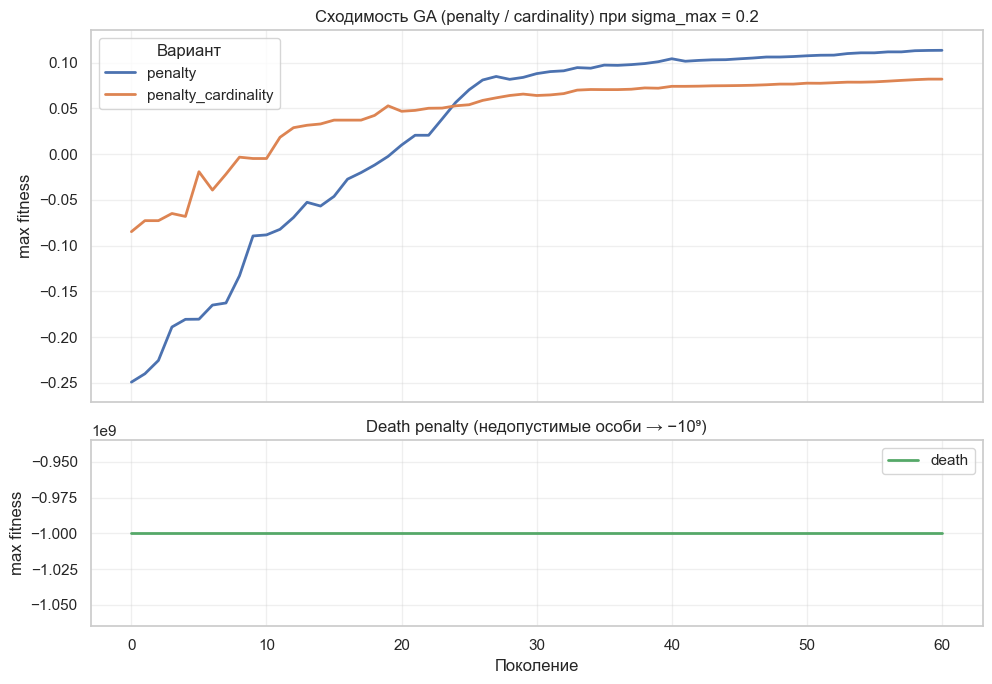

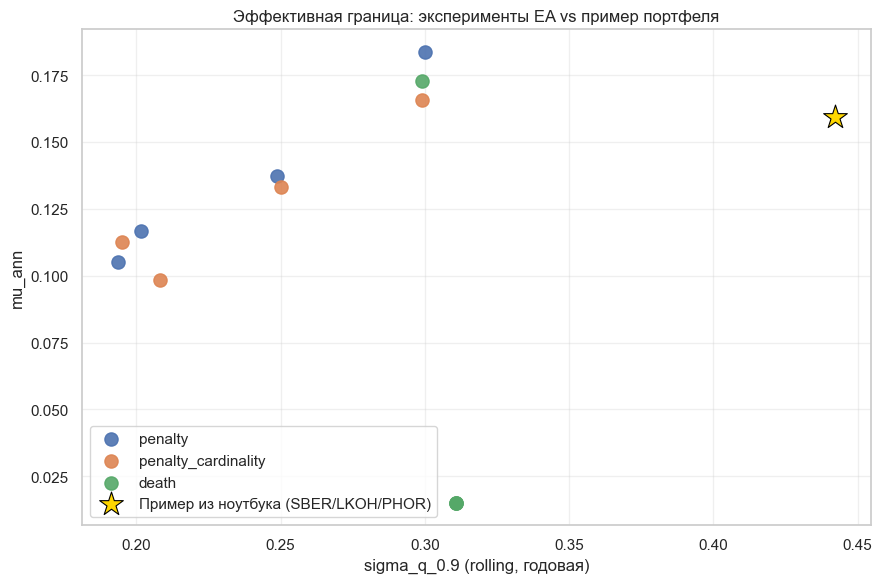

In [75]:
# Сходимость (max fitness по поколениям) при sigma_max = 0.20
# death ~ -1e9 сжимает штрафные кривые на одной оси — разносим по двум подграфикам
fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)
for v, curve in convergence_curves.items():
    if v == "death":
        continue
    ax_top.plot(range(len(curve)), curve, label=v, linewidth=2)
ax_top.set_ylabel("max fitness")
ax_top.set_title(f"Сходимость GA (penalty / cardinality) при sigma_max = {CONVERGENCE_SIGMA}")
ax_top.legend(title="Вариант")
ax_top.grid(True, alpha=0.3)
_ys = [y for vn, cr in convergence_curves.items() if vn != "death" for y in cr]
if _ys:
    _lo, _hi = min(_ys), max(_ys)
    _pad = 0.06 * (_hi - _lo if _hi > _lo else max(abs(_lo), abs(_hi), 0.1) or 0.1)
    ax_top.set_ylim(_lo - _pad, _hi + _pad)
if "death" in convergence_curves:
    _dc = convergence_curves["death"]
    ax_bot.plot(range(len(_dc)), _dc, label="death", color="C2", linewidth=2)
    ax_bot.set_ylabel("max fitness")
    ax_bot.set_title("Death penalty (недопустимые особи → −10⁹)")
    ax_bot.legend()
    ax_bot.grid(True, alpha=0.3)
    ax_bot.margins(y=0.15)
else:
    ax_bot.set_visible(False)
ax_bot.set_xlabel("Поколение")
plt.tight_layout()
plt.show()

# Эффективная граница: (sigma_q_0.9, mu_ann) для всех 12 запусков
plt.figure(figsize=(9, 6))
colors = {"penalty": "C0", "penalty_cardinality": "C1", "death": "C2"}
for v in VARIANTS:
    sub = results_df[results_df["variant"] == v]
    plt.scatter(
        sub["sigma_q_0.9"],
        sub["mu_ann"],
        label=v,
        s=90,
        alpha=0.9,
        c=colors.get(v),
    )

bench_dict = {"SBER": 0.5, "LKOH": 0.1, "PHOR": 0.4}
mu_b, sig_b = metrics_from_weights_vec(vec_from_weight_dict(bench_dict))
plt.scatter(
    [sig_b],
    [mu_b],
    marker="*",
    s=320,
    c="gold",
    edgecolors="black",
    linewidths=0.8,
    zorder=5,
    label="Пример из ноутбука (SBER/LKOH/PHOR)",
)
plt.xlabel("sigma_q_0.9 (rolling, годовая)")
plt.ylabel("mu_ann")
plt.title("Эффективная граница: эксперименты EA vs пример портфеля")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Выбор лучшего портфеля: max mu_ann среди feasible
variant            death
sigma_max            0.3
mu_ann          0.172877
sigma_q_0.9       0.2991
n_assets              12
feasible            True
fitness_best    0.172877

Веса (тикер → доля), ненулевые:
  PHOR         0.3425
  PLZL         0.2262
  USD000UTSTOM 0.0820
  TATNP        0.0719
  FESH         0.0630
  LKOH         0.0546
  MTSS         0.0343
  MOEX         0.0263
  GMKN         0.0259
  NLMK         0.0249
  RUAL         0.0107
  HYDR         0.0103
  TGKN         0.0078
  SNGSP        0.0075
  CNTL         0.0047
  UPRO         0.0035
  BSPB         0.0020
  VTBR         0.0017


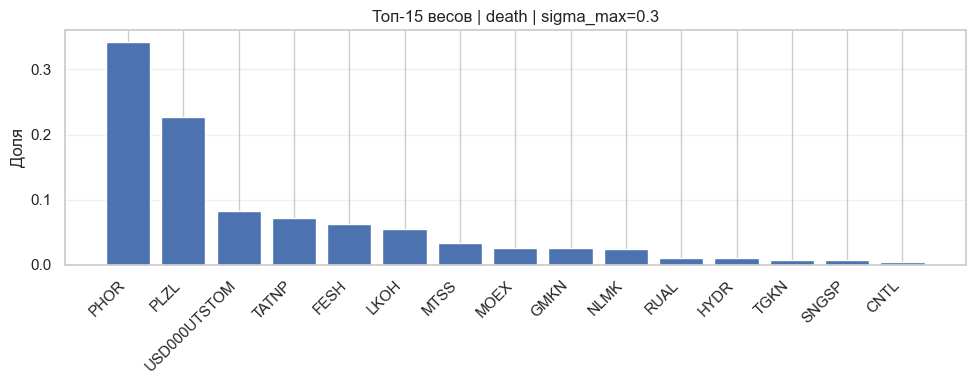

c:\Users\oklad\anaconda3\envs\new\Lib\site-packages\pandas\core\internals\blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)
c:\Users\oklad\anaconda3\envs\new\Lib\site-packages\numpy\core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


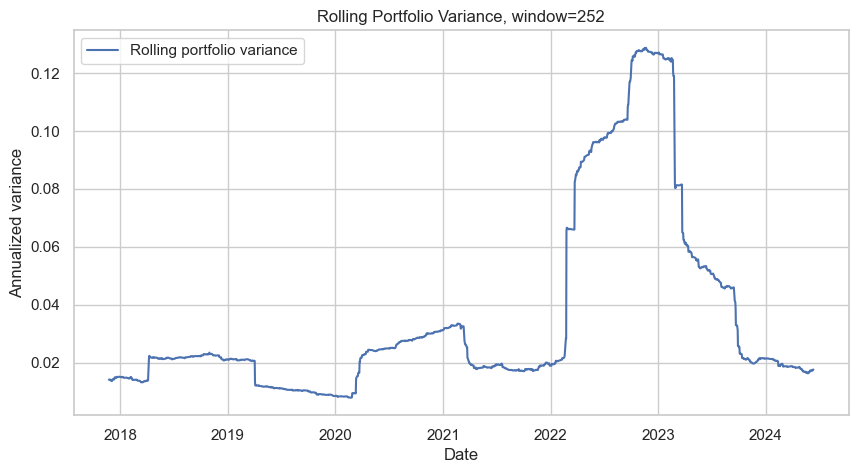

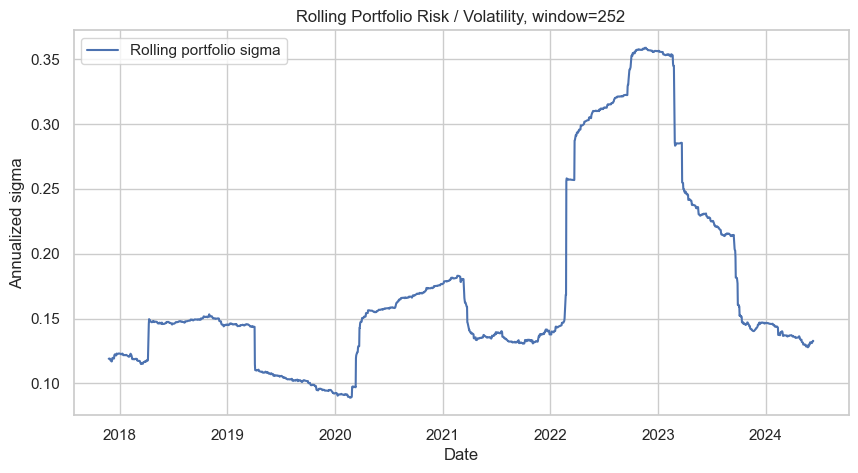

{'weights': LKOH            0.054590
 TATNP           0.071890
 GMKN            0.025912
 NLMK            0.024925
 PLZL            0.226208
 PHOR            0.342528
 MTSS            0.034282
 SNGSP           0.007528
 MOEX            0.026317
 VTBR            0.001718
 HYDR            0.010308
 BSPB            0.002006
 UPRO            0.003471
 RUAL            0.010713
 FESH            0.063038
 TGKN            0.007848
 CNTL            0.004686
 USD000UTSTOM    0.082033
 dtype: float64,
 'mu_ann': nan,
 'rolling_var_ann': 2017-11-24    0.014171
 2017-11-27    0.014202
 2017-11-28    0.014142
 2017-11-29    0.014126
 2017-11-30    0.013873
                 ...   
 2026-04-24         NaN
 2026-04-27         NaN
 2026-04-28         NaN
 2026-04-29         NaN
 2026-04-30         NaN
 Name: rolling_var_ann, Length: 1709, dtype: float64,
 'rolling_sigma_ann': 2017-11-24    0.119041
 2017-11-27    0.119173
 2017-11-28    0.118918
 2017-11-29    0.118852
 2017-11-30    0.117785
          

In [59]:
# Лучший портфель: среди допустимых (feasible) — max mu_ann; иначе минимальное отклонение по риску
feas_df = results_df[results_df["feasible"]]
if len(feas_df):
    best_idx = feas_df["mu_ann"].idxmax()
    pick_reason = "max mu_ann среди feasible"
else:
    best_idx = (results_df["sigma_q_0.9"] - results_df["sigma_max"]).abs().idxmin()
    pick_reason = "нет feasible — минимум |sigma_q_0.9 - sigma_max|"

best_row = results_df.loc[best_idx]
v_best = str(best_row["variant"])
smax_best = float(best_row["sigma_max"])
w_star = ALL_BEST_WEIGHTS[(v_best, smax_best)].copy()
wd_best = weights_dict_from_vec(w_star)

print("Выбор лучшего портфеля:", pick_reason)
print(best_row.to_string())
print("\nВеса (тикер → доля), ненулевые:")
for t, x in sorted(wd_best.items(), key=lambda kv: -kv[1])[:20]:
    print(f"  {t:12s} {x:.4f}")

# Bar-chart топ-15
top = sorted(wd_best.items(), key=lambda kv: -kv[1])[:15]
if top:
    ticks, vals = zip(*top)
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(vals)), vals, tick_label=ticks)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Доля")
    plt.title(f"Топ-15 весов | {v_best} | sigma_max={smax_best}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Полная верификация через portfolio_metrics_rolling (как в постановке задачи)
portfolio_metrics_rolling(
    wd_best,
    prices,
    window=EA_WINDOW,
    trading_days=EA_TRADING_DAYS,
    plot=True,
)